
# モデル学習チュートリアル
このノートブックでは、**CQCNNモデルを用いたガイスターAIの学習**を体験します。  
短いエピソード数での学習 → モデル保存 → 学習状況の可視化 までを行います。


## 必要ライブラリのインポート

In [1]:

import os
import torch
import matplotlib.pyplot as plt
from train import run_geister_cqcnn_training
from utils import set_seed, get_device_info

# 乱数シード設定
set_seed(42)
print("✅ 環境初期化完了")
print("Device Info:", get_device_info())


✅ 環境初期化完了
Device Info: {'device': 'cpu', 'device_name': 'cpu', 'device_properties': {'name': 'cpu', 'capability': None, 'total_memory': None}}


## CQCNNモデルの学習（短期テスト）

In [2]:

# 簡単なテストとして、10エピソードだけ学習を行います。
run_geister_cqcnn_training(episodes=10)


--- Training CQCNN Agent (Qubits: 4, CNN->QNN Feat: 4) ---
Initialized QNN device: lightning.qubit with 4 qubits.
Training finished.
Final Score: A Wins: 5 (50.00%), B Wins: 5 (50.00%), Draws: 0 (0.00%)

--- Evaluating Trained CQCNN Agent A vs Random ---
Game ended: Draw by turn limit.
--- Episode 100/100 ---
Agent A Wins: 27 (27.00%), Agent B Wins: 72 (72.00%), Draws: 1 (1.00%)
Avg Loss A (last 500): nan, Avg Loss B (last 500): nan
Agent A Epsilon: 0.0
Agent B Epsilon: N/A
Training finished.
Final Score: A Wins: 27 (27.00%), B Wins: 72 (72.00%), Draws: 1 (1.00%)


## 学習済みモデルの保存例

In [3]:

# 通常の学習関数 run_geister_cqcnn_training はエピソードごとに自動保存します。
# ここでは、utils.save_agent_2() を使った保存例を示します。

from agent_factory import save_agent_2
from geister_game import GeisterGame
from train import CQCAgent_Geister
import pennylane as qml

game = GeisterGame()
dev = qml.device("lightning.qubit", wires=4)
agent_sample = CQCAgent_Geister(
    player_id="A", game=game, dev_qnn=dev,
    embedding_type="AngleEmbedding", ansatz_type="RealAmplitudes",
    n_qubits_qnn=4, input_channels_cnn=6, board_size_cnn=game.board_size,
    cnn_fc_out_features=4
)

save_agent_2(agent_sample, "./trained_models/sample_test", "CQCNN", name="sample_agent")


💾 Saved weights: sample_agent_weights.pth
📝 Saved config: sample_agent_config.json


## 学習ログ可視化（概略）

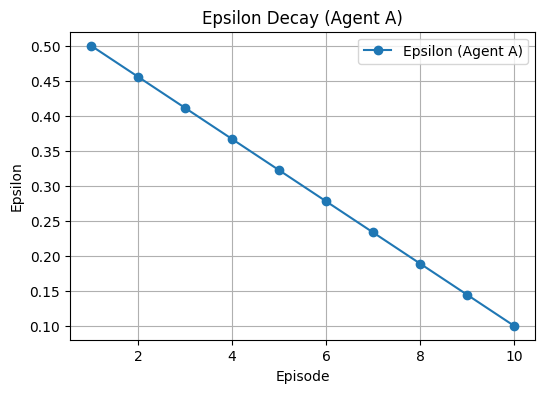

In [4]:

# 現状、train.pyではエピソードごとに標準出力に勝率・epsilonを表示します。
# ここでは学習結果を仮に可視化する例として、ダミーデータを作って可視化します。

import numpy as np

episodes = np.arange(1, 11)
epsilon_A = np.linspace(0.5, 0.1, 10)
wins_A = np.random.randint(0, 10, size=10)

plt.figure(figsize=(6, 4))
plt.plot(episodes, epsilon_A, label='Epsilon (Agent A)', marker='o')
plt.title("Epsilon Decay (Agent A)")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.legend()
plt.grid()
plt.show()



## 次のステップ
- エピソード数を増やし、`run_geister_cqcnn_training_until_epsilon_2()` を用いて十分な学習を実施。
- 学習済みモデル同士の対戦評価（`evaluate.py`）を行い、Eloレーティングを算出。
- 複数モデルを比較するために `compute_elo_rating.py` および `compute_nash_rating_fixed_v2.py` を使用。
